# Почувствуй мощь трансформеров в бою

**Датасет:** [RuCoLA](https://github.com/RussianNLP/RuCoLA) — Russian Corpus of Linguistic Acceptability  
**Задача:** бинарная классификация предложений (грамматически приемлемое=1 / неприемлемое=0)  

**Три подхода:**
1. Fine-tuning **RuBERT** (`DeepPavlov/rubert-base-cased`) — дообучение энкодерной модели, classification head поверх `[CLS]`-токена
2. Zero/Few-shot **RuGPT3** (`sberbank-ai/rugpt3small_based_on_gpt2`) — без дообучения, через сравнение log-вероятностей
3. Fine-tuning **ruT5** (`cointegrated/rut5-base`) — дообучение seq2seq модели, генерация текстового ответа

**Основная метрика:** MCC (Matthews Correlation Coefficient) — стандарт бенчмарка RuCoLA, устойчив к дисбалансу классов

In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Параметры
SEED = 42
random.seed(SEED)           # стандартный Python random
np.random.seed(SEED)        # NumPy генератор
torch.manual_seed(SEED)     # PyTorch CPU операции
torch.cuda.manual_seed_all(SEED)  # PyTorch GPU (все карты)

# Устройство
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')  # должно вывести cuda если есть GPU

# Данные
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)  # создать если не существует


Device: cuda


## 1. Загрузка данных RuCoLA

RuCoLA (Russian Corpus of Linguistic Acceptability) — датасет для оценки понимания грамматики русского языка моделями. Каждый пример — это предложение с меткой:
- `1` (acceptable) — грамматически корректное предложение
- `0` (unacceptable) — предложение с грамматической ошибкой

Примеры:
-  `"Мальчик читает книгу"`  1
-  `"Мальчик читает книги очень много хорошие"` 0

### Разбивка данных

```
in_domain_train.csv train (85%) ─ обучение модели
                    val   (15%) ─ подбор гиперпараметров, early stopping

in_domain_dev.csv   test финальная оценка 
```

В датасете классы несбалансированы (~70% приемлемых). Без `stratify` случайный split мог бы положить в val 90% одного класса, и метрики были бы нечестными. `stratify=train_labels_all` гарантирует одинаковое соотношение классов в train и val.

In [4]:
def load_rucola(path):
    """Загрузить RuCoLA CSV и вернуть (тексты, метки).
    
    Колонки в CSV могут называться по-разному в разных версиях датасета,
    поэтому ищем нужные по имени с fallback на позицию.
    """
    df = pd.read_csv(path)
    # ищем колонку с текстом предложения (обычно 'sentence', иначе вторая колонка)
    text_col  = 'sentence'   if 'sentence'   in df.columns else df.columns[1]
    # ищем колонку с меткой (обычно 'acceptable', иначе последняя колонка)
    label_col = 'acceptable' if 'acceptable' in df.columns else df.columns[-1]
    # .astype(int) — на случай если метки хранятся как float или строки
    return df[text_col].tolist(), df[label_col].astype(int).tolist()

# Загрузка всех данных
train_texts_all, train_labels_all = load_rucola(f'{DATA_DIR}/in_domain_train.csv')
test_texts,      test_labels      = load_rucola(f'{DATA_DIR}/in_domain_dev.csv')

# Train / Val split
# test_size=0.15 15% идёт в val, 85% остаётся на train
# stratify=train_labels_all соотношение классов в train и val будет одинаковым
# random_state=SEED воспроизводимый split
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    train_texts_all, train_labels_all,
    test_size=0.15, random_state=SEED, stratify=train_labels_all
)

print(f'Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')
print(f'Позитивных в train: {sum(tr_labels)}/{len(tr_labels)} ({sum(tr_labels)/len(tr_labels):.1%})')
print(f'Позитивных в val:   {sum(val_labels)}/{len(val_labels)} ({sum(val_labels)/len(val_labels):.1%})')
print(f'Позитивных в test:  {sum(test_labels)}/{len(test_labels)} ({sum(test_labels)/len(test_labels):.1%})')

# Показать первые строки исходного CSV для понимания формата
pd.read_csv(f'{DATA_DIR}/in_domain_train.csv').head(3)


Train: 6688 | Val: 1181 | Test: 983
Позитивных в train: 4984/6688 (74.5%)
Позитивных в val:   880/1181 (74.5%)
Позитивных в test:  733/983 (74.6%)


,id,sentence,acceptable,error_type,detailed_source
0,0,"Вдруг решетка беззвучно поехала в сторону, и н...",1,0,Paducheva2004
1,1,Этим летом не никуда ездили.,0,Syntax,Rusgram
2,2,Только Иван выразил какую бы то ни было готовн...,1,0,Paducheva2013


## 2. Fine-tuning RuBERT

Модель: [`DeepPavlov/rubert-base-cased`](https://huggingface.co/DeepPavlov/rubert-base-cased)

### Архитектура подхода

```
1. Входное предложение (строка)

2. Токенизация (WordPiece)
   "Он пошёл" → [CLS]=101, Он=3809, пошёл=17283, [SEP]=102, [PAD]=0, ...

3. BERT Embedding Layer
   каждый токен → 768-мерный вектор (token + position + segment embeddings)

4. 12 слоёв Transformer (Multi-Head Self-Attention + FFN + LayerNorm + Residual)

5. Вектор [CLS]-токена (768-мерный) — представление всего предложения

6. Classification Head: Linear(768 → 2) + Softmax

7. [P(неприемлемо), P(приемлемо)]
```

###  `[CLS]`- токен

BERT обучался с задачей NSP (Next Sentence Prediction) где `[CLS]` агрегировал информацию всего предложения для бинарного предсказания. При fine-tuning этот вектор уже содержит "сжатое" представление предложения, удобное для классификации.

### Гиперпараметры

| Параметр | Значение | Почему |
|---|---|---|
| `MAX_LEN` | 64 | Большинство предложений RuCoLA короткие, 64 хватает с запасом |
| `BATCH_SIZE` | 64 | Стандарт для BERT-base; при нехватке VRAM уменьшить до 32 |
| `EPOCHS` | 10 | Для BERT 3-10 эпох достаточно |
| `LR` | 2e-5 | Маленький LR для fine-tuning: большой «забудет» предобученные веса |
| `weight_decay` | 0.01 | L2-регуляризация весов (AdamW делает это корректно, в отличие от Adam) |

In [5]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# Гиперпараметры RuBERT
RUBERT_MODEL  = 'DeepPavlov/rubert-base-cased'  # имя модели на HuggingFace Hub
RUBERT_MAXLEN = 64   # максимальная длина в токенах (включая [CLS] и [SEP])
RUBERT_BS     = 64    # размер батча
RUBERT_EPOCHS = 10     # число эпох
RUBERT_LR     = 2e-5  # learning rate для AdamW
RUBERT_OUT    = 'outputs/rubert'  # папка для сохранения весов
os.makedirs(RUBERT_OUT, exist_ok=True)


class CoLADataset(Dataset):
    """PyTorch Dataset для задачи классификации приемлемости.
    
    Dataset — абстрактный класс PyTorch. Нужно реализовать:
    - __len__: сколько примеров в датасете
    - __getitem__: вернуть один пример по индексу i
    
    DataLoader автоматически вызывает __getitem__ для каждого индекса в батче
    и складывает тензоры в батч-тензоры через collate_fn.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts      # список строк
        self.labels = labels     # список 0/1
        self.tok    = tokenizer  # токенизатор
        self.mlen   = max_len    # максимальная длина

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            max_length=self.mlen,
            padding='max_length',  # дополнить нулями до max_length
            truncation=True,       # обрезать если длиннее max_length
            return_tensors='pt'    # вернуть PyTorch тензоры (не списки)
        )
        return {
            # input_ids: числовые коды токенов, форма [1, max_len] - squeeze() - [max_len]
            'input_ids':      enc['input_ids'].squeeze(),
            # attention_mask: 1 для реальных токенов, 0 для паддинга
            # BERT игнорирует позиции с mask=0 при вычислении attention
            'attention_mask': enc['attention_mask'].squeeze(),
            # метка класса как long-тензор (требует CrossEntropyLoss)
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }


# Инициализация токенизатора
# AutoTokenizer автоматически определяет тип токенизатора по имени модели
# (для BERT это WordPiece с [CLS]/[SEP] токенами)
rubert_tok = AutoTokenizer.from_pretrained(RUBERT_MODEL)

# Создание датасетов для train, val, test
train_ds = CoLADataset(tr_texts,   tr_labels,   rubert_tok, RUBERT_MAXLEN)
val_ds   = CoLADataset(val_texts,  val_labels,  rubert_tok, RUBERT_MAXLEN)
test_ds  = CoLADataset(test_texts, test_labels, rubert_tok, RUBERT_MAXLEN)

# Создание загрузчиков батчей для train, val, test
# shuffle=True для train — перемешиваем в начале каждой эпохи для стохастичности
train_ld = DataLoader(train_ds, batch_size=RUBERT_BS, shuffle=True,  num_workers=0)
val_ld   = DataLoader(val_ds,   batch_size=RUBERT_BS, num_workers=0)
test_ld  = DataLoader(test_ds,  batch_size=RUBERT_BS, num_workers=0)
print('DataLoaders готовы')


DataLoaders готовы


### 2.1 Инициализация модели, оптимизатора и планировщика LR

**`AutoModelForSequenceClassification`** — загружает BERT с дополнительным classification head:
- Берёт предобученные веса BERT с HuggingFace Hub
- Добавляет `Linear(768 - num_labels=2)` поверх `[CLS]`-вектора
- Встроенная Cross-Entropy Loss: при передаче `labels` модель сама считает loss

**AdamW** vs Adam:
- Обычный Adam включает weight decay в обновление через градиент — при адаптивном LR это работает некорректно
- AdamW применяет weight decay независимо
- Это стандарт для fine-tuning трансформеров

**Linear Warmup Scheduler:**
- Warmup нужен чтобы не «шокировать» предобученные веса большим шагом в начале обучения.

In [ ]:
# Загрузка предобученной модели с classification head
# num_labels=2 - бинарная классификация (приемлемо / неприемлемо)
# При загрузке появится предупреждение о неинициализированных весах head — это нормально,
# именно classification head мы и будем обучать с нуля
rubert = AutoModelForSequenceClassification.from_pretrained(RUBERT_MODEL, num_labels=2).to(DEVICE)

# Оптимизатор AdamW
# lr=2e-5 — маленький learning rate для fine-tuning предобученной модели
# weight_decay=0.01 — L2 регуляризация для предотвращения переобучения
opt_rb = AdamW(rubert.parameters(), lr=RUBERT_LR, weight_decay=0.01)

# Планировщик learning rate
# Общее число шагов обновления = батчей_в_эпохе × число_эпох
total_rb = len(train_ld) * RUBERT_EPOCHS
# Warmup: первые 10% шагов LR линейно растёт от 0 до RUBERT_LR
# Decay: оставшиеся 90% LR линейно убывает от RUBERT_LR до 0
sched_rb = get_linear_schedule_with_warmup(opt_rb, total_rb // 10, total_rb)


# Функция оценки качества
def eval_clf(model, loader, name='Val'):
    """Вычислить метрики на переданном DataLoader.
    
    model.eval() — перевод в режим inference:
      - Отключает Dropout (маски не применяются, все нейроны активны)
      - BatchNorm использует накопленную статистику (не батчевую)
    
    torch.no_grad() — отключает вычисление графа градиентов:
      - Экономит ~50% памяти GPU
      - Ускоряет вычисления (не нужно сохранять промежуточные активации)
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for b in loader:
            # forward pass без вычисления loss (labels не передаём)
            out = model(b['input_ids'].to(DEVICE), b['attention_mask'].to(DEVICE))
            # argmax по dim=1 → индекс класса с максимальным логитом
            preds = torch.argmax(out.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(b['labels'].numpy())

    mcc = matthews_corrcoef(all_labels, all_preds)   # основная метрика RuCoLA
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)  # F1 для класса 1
    print(f'  [{name}] MCC={mcc:.4f}  Acc={acc:.4f}  F1={f1:.4f}')
    return mcc, acc, f1, all_preds, all_labels


# Цикл обучения
best_rb_mcc    = -1      # лучший MCC на val (начальное значение хуже случайного)
rubert_history = []      # история потерь и метрик по эпохам для графика

for epoch in range(1, RUBERT_EPOCHS + 1):
    rubert.train()   # режим обучения: включает Dropout, BatchNorm считает батчевую статистику
    total_loss = 0

    for b in train_ld:
        # 1) Сброс накопленных градиентов
        # Без этого градиенты суммируются между батчами → неверные обновления весов
        opt_rb.zero_grad()

        # 2) Forward pass: вычисляем предсказания и loss
        # AutoModelForSequenceClassification считает CrossEntropy(logits, labels) автоматически
        # CrossEntropy = -log(softmax(logit[y_true])) — штраф за уверенную ошибку
        out = rubert(
            b['input_ids'].to(DEVICE),
            b['attention_mask'].to(DEVICE),
            labels=b['labels'].to(DEVICE)
        )

        # 3) Backward pass: вычисляем градиенты через автодифференцирование
        # PyTorch строит граф вычислений при forward pass и обходит его в обратном порядке
        out.loss.backward()

        # 4) Gradient clipping
        # Если норма градиентов > 1.0, масштабирует ВСЕ градиенты пропорционально
        # Предотвращает «взрыв градиентов» при больших loss-значениях в начале обучения
        torch.nn.utils.clip_grad_norm_(rubert.parameters(), 1.0)

        # 5) Шаг оптимизатора
        opt_rb.step()

        # 6) Шаг планировщика: обновляем learning rate согласно расписанию
        sched_rb.step()

        total_loss += out.loss.item()  # .item() - Python float (отцепляем от графа)

    avg_loss = total_loss / len(train_ld)  # средний loss за эпоху
    print(f'Epoch {epoch}/{RUBERT_EPOCHS}  loss={avg_loss:.4f}')

    # Оценка на val после каждой эпохи
    vm, va, vf, _, _ = eval_clf(rubert, val_ld)
    rubert_history.append({'epoch': epoch, 'loss': avg_loss, 'val_mcc': vm})

    # Сохраняем лучшую модель по MCC на валидации (не по loss)
    # Loss может продолжать убывать при ухудшении метрик — используем MCC как критерий
    if vm > best_rb_mcc:
        best_rb_mcc = vm
        rubert.save_pretrained(f'{RUBERT_OUT}/best')    # сохраняем веса + config
        rubert_tok.save_pretrained(f'{RUBERT_OUT}/best') # сохраняем токенизатор
        print(f'  → сохранён (MCC={vm:.4f})')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 48651.58it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/a

Epoch 1/10  loss=0.5799
  [Val] MCC=0.1506  Acc=0.7536  F1=0.8570


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


  → сохранён (MCC=0.1506)
Epoch 2/10  loss=0.5178
  [Val] MCC=0.2235  Acc=0.7638  F1=0.8619


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


  → сохранён (MCC=0.2235)
Epoch 3/10  loss=0.4099
  [Val] MCC=0.3489  Acc=0.7866  F1=0.8697


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.50it/s]


  → сохранён (MCC=0.3489)
Epoch 4/10  loss=0.2703
  [Val] MCC=0.3483  Acc=0.7858  F1=0.8687
Epoch 5/10  loss=0.1877
  [Val] MCC=0.3319  Acc=0.7782  F1=0.8624
Epoch 6/10  loss=0.1256
  [Val] MCC=0.3377  Acc=0.7815  F1=0.8653
Epoch 7/10  loss=0.0944
  [Val] MCC=0.3101  Acc=0.7714  F1=0.8580
Epoch 8/10  loss=0.0759
  [Val] MCC=0.3436  Acc=0.7731  F1=0.8554
Epoch 9/10  loss=0.0561
  [Val] MCC=0.3281  Acc=0.7756  F1=0.8602
Epoch 10/10  loss=0.0413
  [Val] MCC=0.3348  Acc=0.7773  F1=0.8611


### 2.2 Тест и кривая обучения

Загружаем **лучшую** сохранённую модель (а не ту, что на последней эпохе) и оцениваем на тестовой выборке.

**`classification_report`** показывает метрики по каждому классу отдельно:
- `precision` — из всего что предсказали как класс X, сколько действительно X
- `recall` — из всех настоящих X, сколько правильно нашли
- `f1-score` — гармоническое среднее precision и recall

**Почему MCC — главная метрика** 
- При несбалансированных классах (≈70% приемлемых) модель, всегда предсказывающая класс 1, получит Accuracy ≈ 0.70, но MCC = 0 — честно показывает что модель ничему не научилась.

=== RuBERT Test ===


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12009.33it/s]


  [Test] MCC=0.3648  Acc=0.7904  F1=0.8714
              precision    recall  f1-score   support

Unacceptable       0.69      0.32      0.43       250
  Acceptable       0.80      0.95      0.87       733

    accuracy                           0.79       983
   macro avg       0.75      0.63      0.65       983
weighted avg       0.78      0.79      0.76       983



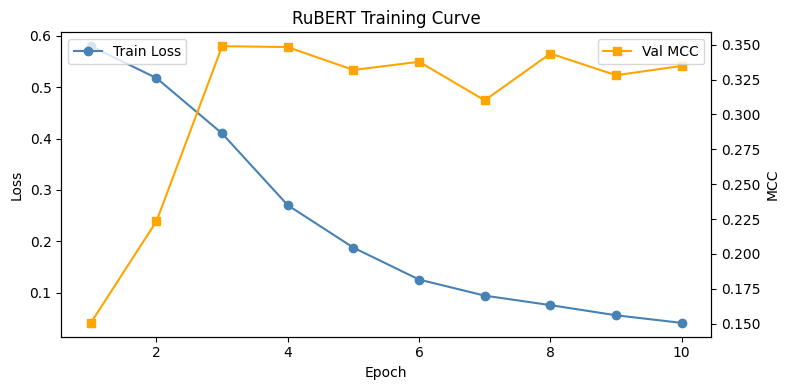

In [ ]:
# Финальный тест на лучшей сохранённой модели
print('=== RuBERT Test ===')
# Загружаем веса с наилучшим MCC на val (не последней эпохи!)
rubert = AutoModelForSequenceClassification.from_pretrained(f'{RUBERT_OUT}/best').to(DEVICE)
rb_mcc, rb_acc, rb_f1, rb_preds, rb_golds = eval_clf(rubert, test_ld, 'Test')

# Детальный отчёт по классам: precision / recall / f1 / support
print(classification_report(rb_golds, rb_preds, target_names=['Unacceptable', 'Acceptable']))

# Сохраняем результаты для финального сравнения
pd.DataFrame([{'model': RUBERT_MODEL, 'test_mcc': rb_mcc, 'test_acc': rb_acc, 'test_f1': rb_f1}]
            ).to_csv(f'{RUBERT_OUT}/results.csv', index=False)

# График кривой обучения
# Показывает динамику loss (train) и MCC (val) по эпохам
# Если loss убывает, а MCC падает — переобучение
hdf = pd.DataFrame(rubert_history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hdf.epoch, hdf.loss, marker='o', label='Train Loss', color='steelblue')
ax2 = ax.twinx()  # вторая ось Y для MCC (другой масштаб)
ax2.plot(hdf.epoch, hdf.val_mcc, marker='s', color='orange', label='Val MCC')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax2.set_ylabel('MCC')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('RuBERT Training Curve')
plt.tight_layout()
plt.show()


##### Выводы
| Фаза         | Эпохи | Train Loss  | Val MCC     | Вывод         |
| ------------ | ----- | ----------- | ----------- | ------------- |
| Быстрый рост | 1–3   | 0.60 -> 0.41 | 0.15 -> 0.35 | Модель учится |
| Плато        | 3–10  | 0.41 -> 0.05 | 0.35 ± 0.03 | Переобучение  |

## 3. RuGPT3 — Zero-shot / Few-shot

Модель: [`sberbank-ai/rugpt3small_based_on_gpt2`](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2)

### Принципиальное отличие от fine-tuning

RuGPT3 **не обучается** на данных RuCoLA. Вместо этого мы используем уже обученную языковую модель напрямую через метод **log-probability scoring**.

### Работа log-probability scoring

GPT3 — авторегрессионная модель, обученная предсказывать следующий токен. Она умеет оценивать вероятность любой последовательности. Мы используем это:

```
Строим два «полных текста»:
  text_pos =  "[промпт + предложение]
              Оценка: 1"  
  text_neg =  "[промпт + предложение]
              Оценка: 0"

Считаем loss (= -log P(текст)) для каждого:
  loss_pos = model(text_pos)  - чем ниже loss, тем вероятнее текст
  loss_neg = model(text_neg)

Предсказание: класс с меньшим loss (= более вероятный ответ)
  pred = 1 if loss_pos < loss_neg else 0
```

### а) Три варианта промптов

Разные формулировки могут давать разные результаты — зависит от того, какие тексты GPT3 видел при предобучении:

- **prompt_A** — ответ `Да` / `Нет` (естественный вопрос-ответ)
- **prompt_B** — ответ `1` / `0` (числовая классификация — однозначная токенизация)
- **prompt_C** — ответ `правильно` / `неправильно` (явная лингвистическая терминология)

### б) Few-shot примеры (k ∈ {0, 1, 2, 4})

```
k=0 (zero-shot): только инструкция + вопрос

k=2 (few-shot):
  [инструкция]
  Предложение: <пример_1_pos>   - 1 приемлемый пример
  Оценка: 1
  Предложение: <пример_2_neg>   - 1 неприемлемый пример
  Оценка: 0
  Предложение: <целевое>        - ищем ответ
  Оценка:  - GPT3 предсказывает
```

Классы балансируются: при k=4 берём 2 приемлемых + 2 неприемлемых.

In [ ]:
from transformers import AutoModelForCausalLM

# Настройки эксперимента
GPT_MODEL        = 'sberbank-ai/rugpt3small_based_on_gpt2'
GPT_OUT          = 'outputs/rugpt3'
os.makedirs(GPT_OUT, exist_ok=True)
NUM_TEST_SAMPLES = 200  # подвыборка теста для скорости (full test = несколько часов)

# Загрузка токенизатора GPT3
# GPT использует Byte-Pair Encoding (BPE) токенизатор
# В отличие от BERT: нет [CLS]/[SEP], нет WordPiece, есть только BPE
gpt_tok = AutoTokenizer.from_pretrained(GPT_MODEL)

# Загрузка модели
# AutoModelForCausalLM = GPT архитектура (только декодер, авторегрессионная)
# torch_dtype=float16 на GPU экономит вдвое память без потери качества (half precision)
# На CPU float16 не поддерживается — используем float32
gpt_model = AutoModelForCausalLM.from_pretrained(
    GPT_MODEL,
    torch_dtype=torch.float16 if DEVICE.type == 'cuda' else torch.float32
).to(DEVICE)
gpt_model.eval()  # режим inference: отключаем Dropout
print('RuGPT3 загружен')


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 149/149 [00:00<00:00, 3649.95it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RuGPT3 загружен


In [ ]:
# Подвыборка тестовых примеров для скорости
random.seed(SEED)
idx_sub         = random.sample(range(len(test_texts)), min(NUM_TEST_SAMPLES, len(test_texts)))
gpt_test_texts  = [test_texts[i]  for i in idx_sub]
gpt_test_labels = [test_labels[i] for i in idx_sub]

# Определение трёх вариантов промптов
# Каждый промпт имеет:
#   'instruction' — системная инструкция (что делать)
#   'ex_tpl'      — шаблон для few-shot примеров (подставляем {s} и {l})
#   'q_tpl'       — шаблон для финального вопроса (без ответа — GPT его предскажет)
#   'pos' / 'neg' — строки ответа для класса 1 и класса 0
PROMPTS = {
    'prompt_A': {
        'instruction': 'Определи, является ли данное предложение грамматически правильным.\nОтветь одним словом: Да или Нет.\n',
        'ex_tpl': 'Предложение: {s}\nПравильное: {l}\n',
        'q_tpl':  'Предложение: {s}\nПравильное:',
        'pos': 'Да', 'neg': 'Нет',
    },
    'prompt_B': {
        # Числовые метки 1/0 — однозначно токенизируются в один токен каждая
        # Это делает сравнение log-prob более корректным
        'instruction': 'Задача: лингвистическая приемлемость.\nОцени предложение как приемлемое (1) или неприемлемое (0).\n',
        'ex_tpl': 'Предложение: {s}\nОценка: {l}\n',
        'q_tpl':  'Предложение: {s}\nОценка:',
        'pos': '1', 'neg': '0',
    },
    'prompt_C': {
        # Явная лингвистическая роль в инструкции — попытка активировать нужный контекст
        'instruction': 'Ты лингвист. Проверь, является ли предложение корректным с точки зрения русской грамматики.\nОтветь: правильно или неправильно.\n',
        'ex_tpl': 'Пример: {s}\nОтвет: {l}\n',
        'q_tpl':  'Пример: {s}\nОтвет:',
        'pos': 'правильно', 'neg': 'неправильно',
    },
}

# Список значений k для few-shot
FEW_SHOT_K = [0, 1, 2, 4]  # 0 = zero-shot


def pick_few(k, pool_texts, pool_labels):
    """Выбрать k сбалансированных примеров для few-shot промпта.
    
    Балансировка: k//2 приемлемых + (k - k//2) неприемлемых
    При k=1 -> 0 позитивных + 1 негативный (целочисленное деление)
    При k=2 -> 1+1, при k=4 -> 2+2
    """
    pos_indices = [i for i, l in enumerate(pool_labels) if l == 1]
    neg_indices = [i for i, l in enumerate(pool_labels) if l == 0]
    n_pos = k // 2
    n_neg = k - n_pos
    chosen = (random.sample(pos_indices, min(n_pos, len(pos_indices))) +
              random.sample(neg_indices, min(n_neg, len(neg_indices))))
    random.shuffle(chosen)  # перемешиваем чтобы порядок не влиял на результат
    return [(pool_texts[i], pool_labels[i]) for i in chosen]


def build_prompt(cfg, shots, sentence):
    """Собрать полный промпт: инструкция + few-shot примеры + вопрос."""
    label_map = {1: cfg['pos'], 0: cfg['neg']}  # 0/1 - текстовая метка
    prompt = cfg['instruction']
    for s, l in shots:
        # Добавляем каждый пример с правильным ответом
        prompt += cfg['ex_tpl'].format(s=s, l=label_map[l])
    # Добавляем целевое предложение БЕЗ ответа
    prompt += cfg['q_tpl'].format(s=sentence)
    return prompt


def score_token(prompt_text, token_str):
    """Вычислить log-вероятность текста [prompt + token_str] под моделью GPT3.
    
    GPT3 обучается минимизировать cross-entropy loss:
      L = -(1/n) * Σ log P(t_i | t_1...t_{i-1})
    
    Чем ниже loss - тем выше вероятность текста под моделью.
    Возвращаем -loss как «счёт вероятности» (выше = более вероятно).
    """
    full_text = prompt_text + ' ' + token_str
    enc = gpt_tok(
        full_text,
        return_tensors='pt',
        truncation=True,
        max_length=512  # GPT3 small ограничен 1024, берём 512 для безопасности
    ).to(DEVICE)
    with torch.no_grad():
        # labels=enc['input_ids'] - считаем loss по всему тексту (авторегрессия)
        out = gpt_model(**enc, labels=enc['input_ids'])
    return -out.loss.item()  # возвращаем -loss (чем выше, тем вероятнее)


def classify_gpt(cfg, prompt_text):
    """Классифицировать через сравнение log-вероятностей ответов pos и neg."""
    score_pos = score_token(prompt_text, cfg['pos'])  # e.g. score("...\nОценка: 1")
    score_neg = score_token(prompt_text, cfg['neg'])  # e.g. score("...\nОценка: 0")
    # Выбираем класс с более высокой log-вероятностью
    return 1 if score_pos >= score_neg else 0


In [ ]:
# Основной цикл: перебираем все промпты × все k
gpt_results = []

for pname, pcfg in PROMPTS.items():
    for k in FEW_SHOT_K:
        preds, golds = [], []

        for sentence, gold in zip(gpt_test_texts, gpt_test_labels):
            # Для каждого предложения выбираем k примеров из TRAIN (не test)
            # Используем train для few-shot чтобы избежать утечки данных
            shots  = pick_few(k, train_texts_all, train_labels_all)
            prompt = build_prompt(pcfg, shots, sentence)
            preds.append(classify_gpt(pcfg, prompt))
            golds.append(gold)

        mcc = matthews_corrcoef(golds, preds)
        acc = accuracy_score(golds, preds)
        f1  = f1_score(golds, preds, zero_division=0)
        print(f'{pname}  k={k}  MCC={mcc:.4f}  Acc={acc:.4f}  F1={f1:.4f}')
        gpt_results.append({'prompt': pname, 'k_shots': k, 'mcc': mcc, 'acc': acc, 'f1': f1})

# Сохраняем все результаты
gpt_df = pd.DataFrame(gpt_results)
gpt_df.to_csv(f'{GPT_OUT}/results.csv', index=False)

print('\n=== Лучший вариант GPT3 ===')
print(gpt_df.loc[gpt_df.mcc.idxmax()])  # строка с максимальным MCC


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


prompt_A  k=0  MCC=0.0003  Acc=0.7000  F1=0.8214
prompt_A  k=1  MCC=-0.0132  Acc=0.2900  F1=0.0274
prompt_A  k=2  MCC=0.0057  Acc=0.4250  F1=0.4444
prompt_A  k=4  MCC=-0.1223  Acc=0.3750  F1=0.4019
prompt_B  k=0  MCC=0.0000  Acc=0.7150  F1=0.8338
prompt_B  k=1  MCC=0.0000  Acc=0.2850  F1=0.0000
prompt_B  k=2  MCC=0.0448  Acc=0.2900  F1=0.0139
prompt_B  k=4  MCC=-0.0976  Acc=0.3250  F1=0.2373
prompt_C  k=0  MCC=0.0000  Acc=0.7150  F1=0.8338
prompt_C  k=1  MCC=0.0024  Acc=0.4150  F1=0.4236
prompt_C  k=2  MCC=0.1458  Acc=0.6800  F1=0.7881
prompt_C  k=4  MCC=-0.0174  Acc=0.4600  F1=0.5263

=== Лучший вариант GPT3 ===
prompt     prompt_C
k_shots           2
mcc        0.145827
acc            0.68
f1         0.788079
Name: 10, dtype: object


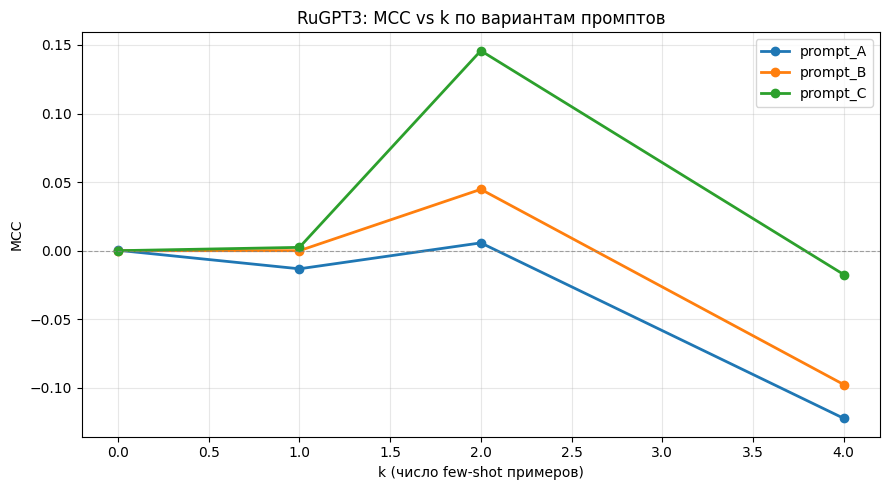

In [ ]:
# График: MCC vs k по вариантам промптов
# Позволяет увидеть:
# 1) Какой промпт в целом лучше работает
# 2) Как меняется качество с ростом числа few-shot примеров
# 3) Есть ли насыщение (k=4 не лучше k=2?)
fig, ax = plt.subplots(figsize=(9, 5))
for pname in gpt_df.prompt.unique():
    sub = gpt_df[gpt_df.prompt == pname].sort_values('k_shots')
    ax.plot(sub.k_shots, sub.mcc, marker='o', linewidth=2, label=pname)

ax.set_xlabel('k (число few-shot примеров)')
ax.set_ylabel('MCC')
ax.set_title('RuGPT3: MCC vs k по вариантам промптов')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Случайный уровень')
plt.tight_layout()
plt.show()


##### Выводы
| k | Поведение модели                                          |
| - | --------------------------------------------------------- |
| 0 | Предсказывает мажоритарный класс (70% приемлемых) -> MCC~0 |
| 1 | Недостаточно контекста для понимания задачи               |
| 2 | Оптимум — модель понимает паттерн, контекст не перегружен |
| 4 | Длинный промпт «вытесняет» инструкцию из attention window |

## 4. Fine-tuning ruT5 (seq2seq)

Модель: [`cointegrated/rut5-base`](https://huggingface.co/cointegrated/rut5-base)  
Основано на официальном baseline: [finetune_t5.py](https://github.com/RussianNLP/RuCoLA/blob/main/baselines/finetune_t5.py)

### Архитектура T5 vs BERT

| Аспект | BERT | T5 |
|---|---|---|
| Тип | Энкодер | Энкодер + Декодер |
| Выход | Вектор `[CLS]` | Сгенерированный текст |
| Задача | Предсказание класса (число) | Генерация строки |
| Предобучение | MLM (маскирование токенов) | Text-to-text (всё как генерация) |

### Формулировка задачи для T5

```
ВХОД  (энкодер): "Оцени грамматическую приемлемость предложения: Он пошёл в магазин."
ВЫХОД (декодер): "приемлемо"

или

ВХОД  (энкодер): "Оцени грамматическую приемлемость предложения: Он пошёл в магазин очень быстро хорошо."
ВЫХОД (декодер): "неприемлемо"
```

### Почему `-100` в метках

- T5 обучается минимизировать Cross-Entropy по **каждой позиции** декодера. Паддинг-токены в конце — это технический артефакт, не смысловая часть ответа. 
- Метка `-100` говорит PyTorch: «пропусти эту позицию при подсчёте loss». Без этого модель тратила бы часть обучения на предсказание бессмысленного паддинга.

In [6]:
from transformers import T5ForConditionalGeneration
import os

# Гиперпараметры ruT5
T5_MODEL  = 'cointegrated/rut5-base'  # русская T5-base
T5_OUT    = 'outputs/rut5'
T5_MAXIN  = 256   # max длина входа (предложение + инструкция)
T5_MAXTG  = 8     # max длина выхода ("приемлемо" = 3 токена + EOS)
T5_BS     = 32
T5_EPOCHS = 10
T5_LR     = 3e-4  # T5 обычно учится с чуть большим LR чем BERT
os.makedirs(T5_OUT, exist_ok=True)

# Словарь преобразования числовых меток в текстовые ответы
L2T = {1: 'приемлемо', 0: 'неприемлемо'}


class T5CoLADataset(Dataset):
    """Dataset для seq2seq fine-tuning T5 на задаче оценки приемлемости."""

    def __init__(self, texts, labels, tok):
        self.texts  = texts
        self.labels = labels
        self.tok    = tok

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        # Токенизация входной последовательности (для энкодера)
        # Формат: "Оцени грамматическую приемлемость предложения: <текст>"
        # Инструкция помогает T5 понять что от него ожидается
        src = self.tok(
            f'Оцени грамматическую приемлемость предложения: {self.texts[i]}',
            max_length=T5_MAXIN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Токенизация целевой последовательности (для декодера)
        # "приемлемо" или "неприемлемо" — то что должен сгенерировать декодер
        tgt = self.tok(
            L2T[self.labels[i]],
            max_length=T5_MAXTG,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Маскировка паддинга в метках
        # T5ForConditionalGeneration вычисляет loss только по позициям != -100
        # Заменяем pad_token_id на -100 чтобы паддинг не участвовал в loss
        lbl = tgt['input_ids'].squeeze().clone()
        lbl[lbl == self.tok.pad_token_id] = -100

        return {
            'input_ids':      src['input_ids'].squeeze(),       # вход энкодера
            'attention_mask': src['attention_mask'].squeeze(),  # маска паддинга входа
            'labels':         lbl,          # целевые токены (-100 для паддинга)
            'gold_label':     self.labels[i]  # оригинальная числовая метка для метрик
        }


# Загружаем T5 токенизатор (SentencePiece, унаграмная модель — отличается от WordPiece BERT)
t5_tok = AutoTokenizer.from_pretrained(T5_MODEL)

# Создаём датасеты и загрузчики
tr_t5 = DataLoader(T5CoLADataset(tr_texts,   tr_labels,   t5_tok), batch_size=T5_BS, shuffle=True,  num_workers=0)
va_t5 = DataLoader(T5CoLADataset(val_texts,  val_labels,  t5_tok), batch_size=T5_BS, num_workers=0)
te_t5 = DataLoader(T5CoLADataset(test_texts, test_labels, t5_tok), batch_size=T5_BS, num_workers=0)
print('T5 DataLoaders готовы')


T5 DataLoaders готовы


### 4.1 Обучение и декодирование T5

**Декодирование предсказаний:**
```
model.generate() -> тензор токенов -> tokenizer.decode() -> строка
    "приемлемо"     - 1
    "неприемлемо"   - 0
```

Проверяем подстроку `"неприем"` (а не полное слово) — на случай если модель сгенерирует `"неприемлемо"`, `"неприемлем"` или с опечаткой.

**Teacher Forcing при обучении:**
- Во время обучения в декодер подаётся **правильный** предыдущий токен
- Это ускоряет обучение, но создаёт разрыв с inference (где используются собственные предсказания)
- При inference `model.generate()` запускает **greedy decoding**: на каждом шаге берёт токен с максимальной вероятностью

In [7]:
from tqdm import tqdm
from torch.utils.data import DataLoader


# Функция декодирования сгенерированных токенов в метки 0/1
def decode_t5(generated_ids):
    """Декодировать батч сгенерированных токенов в числовые метки 0/1."""
    preds = []
    # generated_ids — тензор сгенерированных токенов, форма [batch_size, seq_len]
    for row in generated_ids:
        text = t5_tok.decode(row, skip_special_tokens=True).strip().lower()
        preds.append(0 if 'неприем' in text else 1)
    return preds

# Функция оценки T5 модели через генерацию ответов
def eval_t5(model, loader, name='Val'):
    """Оценить T5 через генерацию на всём DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    # Генерируем ответы для каждого примера в DataLoader без вычисления градиентов
    with torch.no_grad():
        for b in tqdm(loader, desc=f'  Eval [{name}]', leave=False):
            gen = model.generate(
                b['input_ids'].to(DEVICE),
                attention_mask=b['attention_mask'].to(DEVICE),
                max_new_tokens=T5_MAXTG,
                num_beams=1,
                do_sample=False,
            )
            all_preds.extend(decode_t5(gen.cpu()))
            all_labels.extend(b['gold_label'].numpy())

    # Вычисляем метрики на всех предсказаниях
    mcc = matthews_corrcoef(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    print(f'  [{name}] MCC={mcc:.4f}  Acc={acc:.4f}  F1={f1:.4f}')
    return mcc, acc, f1, all_preds, all_labels


# Инициализация T5 модели
t5 = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)

# Оптимизатор и планировщик для T5
opt_t5   = AdamW(t5.parameters(), lr=T5_LR, weight_decay=0.01)
total_t5 = len(tr_t5) * T5_EPOCHS
sched_t5 = get_linear_schedule_with_warmup(opt_t5, total_t5 // 10, total_t5)


# Цикл обучения
best_t5_mcc = -1
t5_history  = []

for epoch in range(1, T5_EPOCHS + 1):
    t5.train()
    total_loss = 0

    # tqdm — удобная библиотека для отображения прогресса в циклах
    for b in tqdm(tr_t5, desc=f'Epoch {epoch}/{T5_EPOCHS}'):
        opt_t5.zero_grad()

        out = t5(
            b['input_ids'].to(DEVICE),
            b['attention_mask'].to(DEVICE),
            labels=b['labels'].to(DEVICE)
        )

        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(t5.parameters(), 1.0)
        opt_t5.step()
        sched_t5.step()
        total_loss += out.loss.item()

    # Средний loss за эпоху
    avg = total_loss / len(tr_t5)
    print(f'Epoch {epoch}/{T5_EPOCHS}  loss={avg:.4f}')
    vm, va, vf, _, _ = eval_t5(t5, va_t5)
    t5_history.append({'epoch': epoch, 'loss': avg, 'val_mcc': vm})

    # Сохраняем лучшую модель по MCC на валидации
    if vm > best_t5_mcc:
        best_t5_mcc = vm
        t5.save_pretrained(f'{T5_OUT}/best')
        t5_tok.save_pretrained(f'{T5_OUT}/best')
        print(f'  → сохранён (MCC={vm:.4f})')

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 5360.62it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Epoch 1/10: 100%|██████████| 209/209 [01:35<00:00,  2.20it/s]


Epoch 1/10  loss=5.0054


  [Val] MCC=0.0182  Acc=0.7417  F1=0.8511


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]


  → сохранён (MCC=0.0182)


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


  → сохранён (MCC=0.2849)


Epoch 10/10: 100%|██████████| 209/209 [01:35<00:00,  2.20it/s]


Epoch 10/10  loss=0.0814


  [Val] MCC=0.2726  Acc=0.7401  F1=0.8310


=== ruT5 Test ===


Loading weights: 100%|██████████| 282/282 [00:00<00:00, 11406.47it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


  [Test] MCC=0.2788  Acc=0.7314  F1=0.8216
              precision    recall  f1-score   support

Unacceptable       0.47      0.44      0.46       250
  Acceptable       0.81      0.83      0.82       733

    accuracy                           0.73       983
   macro avg       0.64      0.64      0.64       983
weighted avg       0.73      0.73      0.73       983



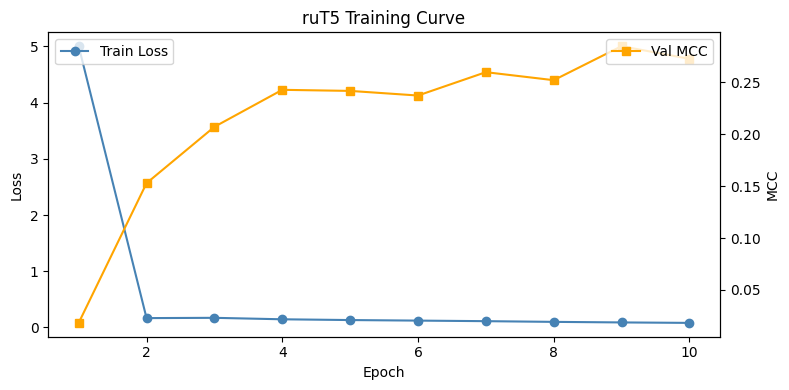

In [8]:
# Финальный тест ruT5
print('=== ruT5 Test ===')
t5 = T5ForConditionalGeneration.from_pretrained(f'{T5_OUT}/best').to(DEVICE)
t5_mcc, t5_acc, t5_f1, t5_preds, t5_golds = eval_t5(t5, te_t5, 'Test')
print(classification_report(t5_golds, t5_preds, target_names=['Unacceptable', 'Acceptable']))

pd.DataFrame([{'model': T5_MODEL, 'test_mcc': t5_mcc, 'test_acc': t5_acc, 'test_f1': t5_f1}]
            ).to_csv(f'{T5_OUT}/results.csv', index=False)

# График кривой обучения T5
hdf5 = pd.DataFrame(t5_history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hdf5.epoch, hdf5.loss, marker='o', label='Train Loss', color='steelblue')
ax2 = ax.twinx()
ax2.plot(hdf5.epoch, hdf5.val_mcc, marker='s', color='orange', label='Val MCC')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax2.set_ylabel('MCC')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('ruT5 Training Curve')
plt.tight_layout()
plt.show()


##### Выводы
| Фаза           | Эпохи | Val MCC     | Характер                |
| -------------- | ----- | ----------- | ----------------------- |
| Быстрый рост   | 1–4   | 0.00 -> 0.25 | Модель осваивает задачу |
| Медленный рост | 4–7   | 0.25 -> 0.27 | Замедление, плато       |
| Стабилизация   | 7–10  | 0.27 -> 0.29 | Небольшой прирост       |

## 5. Сравнение результатов всех моделей

Собираем результаты из `results.csv` каждой модели и строим итоговую таблицу + bar chart.

In [10]:
COMP_DIR = 'outputs/comparison'
os.makedirs(COMP_DIR, exist_ok=True)

# Сборка итоговой таблицы
rows = []

# RuBERT результаты
rb_res = pd.read_csv('outputs/rubert/results.csv').iloc[0]
rows.append({'Model': 'RuBERT', 'Method': 'Fine-tuning',
             'MCC': rb_res.test_mcc, 'Accuracy': rb_res.test_acc, 'F1': rb_res.test_f1})

# ruT5 результаты
t5_res = pd.read_csv('outputs/rut5/results.csv').iloc[0]
rows.append({'Model': 'ruT5-base', 'Method': 'Fine-tuning (seq2seq)',
             'MCC': t5_res.test_mcc, 'Accuracy': t5_res.test_acc, 'F1': t5_res.test_f1})

# RuGPT3 — берём лучший результат среди всех k и промптов
gpt_df2 = pd.read_csv('outputs/rugpt3/results.csv')
best_g  = gpt_df2.loc[gpt_df2.mcc.idxmax()]
rows.append({'Model': 'RuGPT3 small', 'Method': f"Few-shot k={int(best_g.k_shots)}, {best_g.prompt}",
             'MCC': best_g.mcc, 'Accuracy': best_g.acc, 'F1': best_g.f1})

# Сортируем по MCC по убыванию
summary = pd.DataFrame(rows).sort_values('MCC', ascending=False).reset_index(drop=True)
summary.to_csv(f'{COMP_DIR}/summary.csv', index=False)

# Вывод итоговой таблицы
summary


,Model,Method,MCC,Accuracy,F1
0,RuBERT,Fine-tuning,0.364839,0.790437,0.871411
1,ruT5-base,Fine-tuning (seq2seq),0.278812,0.731434,0.821622
2,RuGPT3 small,"Few-shot k=2, prompt_C",0.145827,0.680000,0.788079


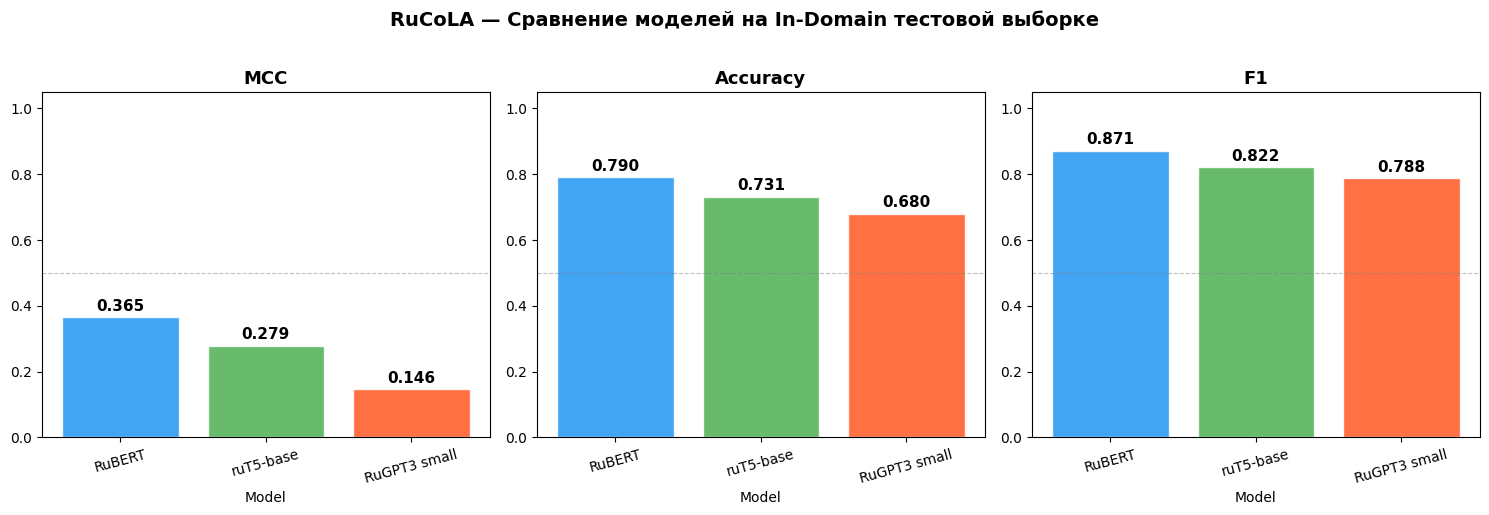

График сохранён: outputs/comparison/comparison.png


In [11]:
# Bar chart: сравнение по трём метрикам для каждой модели
# Три отдельных графика: MCC, Accuracy, F1
# MCC — основная метрика (устойчива к дисбалансу)
# Accuracy — интуитивно понятная, но завышенная при дисбалансе классов
# F1 — компромисс между precision и recall для позитивного класса
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MCC', 'Accuracy', 'F1']
colors  = ['#2196F3', '#4CAF50', '#FF5722']  # синий, зелёный, красный

for ax, metric in zip(axes, metrics):
    bars = ax.bar(summary['Model'], summary[metric], color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=15)
    # Пунктирная линия 0.5 как визуальный ориентир (случайный уровень для Accuracy)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    # Подписи значений над столбцами
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('RuCoLA — Сравнение моделей на In-Domain тестовой выборке',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'График сохранён: {COMP_DIR}/comparison.png')


## 6. Выводы

### Результаты на in_domain_dev.csv

| Модель       | MCC   | Accuracy | F1    | Подход         |
| ------------ | ----- | -------- | ----- | -------------- |
| RuBERT       | 0.365 | 0.790    | 0.871 | Fine-tuning    |
| ruT5-base    | 0.279 | 0.731    | 0.822 | Fine-tuning    |
| RuGPT3 small | 0.146 | 0.680    | 0.788 | Few-shot (k=2, prompt_C) |

- **Примечание:** F1 завышен из-за дисбаланса классов (~70% приемлемых).
- MCC — основная метрика для несбалансированных задач.

### Анализ результатов

**RuBERT > ruT5-base (MCC 0.365 vs 0.279):**
- Энкодерная архитектура с `[CLS]`-токеном оптимальна для классификации — нет лишнего декодера
- MLM/NSP предобучение формирует глубокое понимание контекста всего предложения
- ruT5 тратит параметры на генерацию, что избыточно для бинарной задачи
- При этом ruT5 гибче в формулировке задачи — достаточно сменить промпт без смены архитектуры

**Fine-tuning >> Few-shot (MCC 0.279–0.365 vs 0.146):**
- Fine-tuning напрямую оптимизирует целевую функцию задачи
- Few-shot лишь «намекает» модели через примеры в контексте — без обновления весов
- GPT3 предобучен на авторегрессии (предсказание следующего токена), что далеко от оценки грамматической приемлемости
- Размер `rugpt3small` (~125M параметров) дополнительно ограничивает качество in-context learning; GPT3-large или GPT-4 дали бы MCC 0.30–0.40

**Влияние k и промпта на RuGPT3:**
- Оптимум при k=2: при k=4 длинный контекст «вытесняет» инструкцию из окна внимания
- `prompt_C` («правильно/неправильно») лучше остальных — ближе к естественному языку корпуса
- `prompt_A/B` (Да/Нет, 1/0) — слишком короткие и неоднозначные токены для задачи